# TCGA Processed Dataset — EDA

Verify the processed TCGA dataset before training: class balance, expression distributions, PCA, and cancer type breakdown.

In [11]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
os.chdir(ROOT)

pd.set_option('display.max_columns', 20)

## 1. Load Processed Data

In [12]:
X      = pd.read_csv('data/processed/tcga/expression_matched.csv.gz', index_col=0)
labels = pd.read_csv('data/processed/tcga/tp53_labels.csv')
meta   = pd.read_csv('data/processed/tcga/sample_metadata.csv')

print('Expression:', X.shape)
print('Labels:    ', labels.shape)
print('Metadata:  ', meta.shape)
print('NaN values in expression:', X.isnull().sum().sum())
X.iloc[:5, :6]

Expression: (9701, 20281)
Labels:     (9701, 4)
Metadata:   (9701, 3)
NaN values in expression: 0


,A1BG,A1CF,A2BP1,A2LD1,A2M,A2ML1
sample_id,,,,,,
TCGA-OR-A5J1-01,4.12,0.00,4.19,7.52,13.34,5.80
TCGA-OR-A5J2-01,3.41,0.00,2.73,7.91,13.27,0.00
TCGA-OR-A5J3-01,4.44,0.67,3.31,7.13,12.81,1.47
TCGA-OR-A5J5-01,10.73,1.35,2.85,6.02,11.52,5.66
TCGA-OR-A5J6-01,9.23,0.00,2.45,7.90,13.23,1.08


In [13]:
labels.head(10)

,sample_id,mutation_type,mutation_type_collapsed,tp53_mutant
0,TCGA-OR-A5J1-01,WT,WT,0
1,TCGA-OR-A5J2-01,Frame_Shift_Del,Frameshift,1
2,TCGA-OR-A5J3-01,WT,WT,0
3,TCGA-OR-A5J5-01,Missense_Mutation,Missense,1
4,TCGA-OR-A5J6-01,WT,WT,0
5,TCGA-OR-A5J7-01,WT,WT,0
6,TCGA-OR-A5J8-01,Silent,Other,1
7,TCGA-OR-A5J9-01,WT,WT,0
8,TCGA-OR-A5JA-01,Nonsense_Mutation,Nonsense,1
9,TCGA-OR-A5JB-01,Missense_Mutation,Missense,1


## 2. Class Balance

In [14]:
# Binary
binary = labels['tp53_mutant'].value_counts().rename({0: 'Wild-type', 1: 'Mutant'})
binary_pct = (binary / binary.sum() * 100).round(1)
pd.DataFrame({'count': binary, 'percentage': binary_pct})

,count,percentage
tp53_mutant,,
Wild-type,6571,67.7
Mutant,3130,32.3


In [15]:
# Multiclass
mc = labels['mutation_type_collapsed'].value_counts()
mc_pct = (mc / mc.sum() * 100).round(2)
pd.DataFrame({'count': mc, 'percentage': mc_pct})

,count,percentage
mutation_type_collapsed,,
WT,6571,67.74
Missense,1949,20.09
Nonsense,444,4.58
Frameshift,401,4.13
Splice,215,2.22
Other,121,1.25


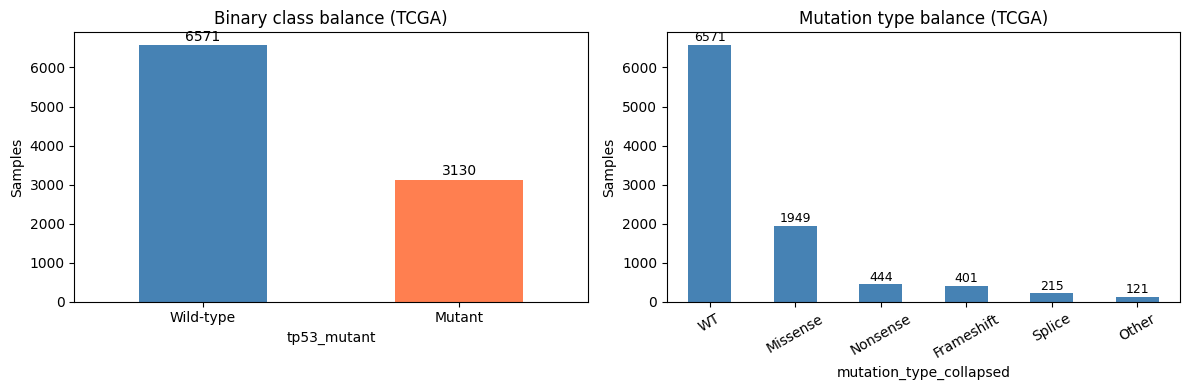

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

binary.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Binary class balance (TCGA)')
axes[0].set_ylabel('Samples')
axes[0].tick_params(axis='x', rotation=0)
for bar, val in zip(axes[0].patches, binary):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 str(val), ha='center', va='bottom', fontsize=10)

mc.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Mutation type balance (TCGA)')
axes[1].set_ylabel('Samples')
axes[1].tick_params(axis='x', rotation=30)
for bar, val in zip(axes[1].patches, mc):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**Interpretation:** TCGA is heavily wild-type dominated (68% WT vs 32% mutant), the opposite of CCLE (42% WT). This reflects real tumour biology — only ~50% of all cancers carry a TP53 mutation, and TCGA covers all cancer types including many TP53-low ones like thyroid and kidney. For the multiclass task, Missense dominates as expected (it is the most common gain-of-function mechanism), while Other (121 samples) will be the hardest class to predict reliably.

## 3. Expression Distribution

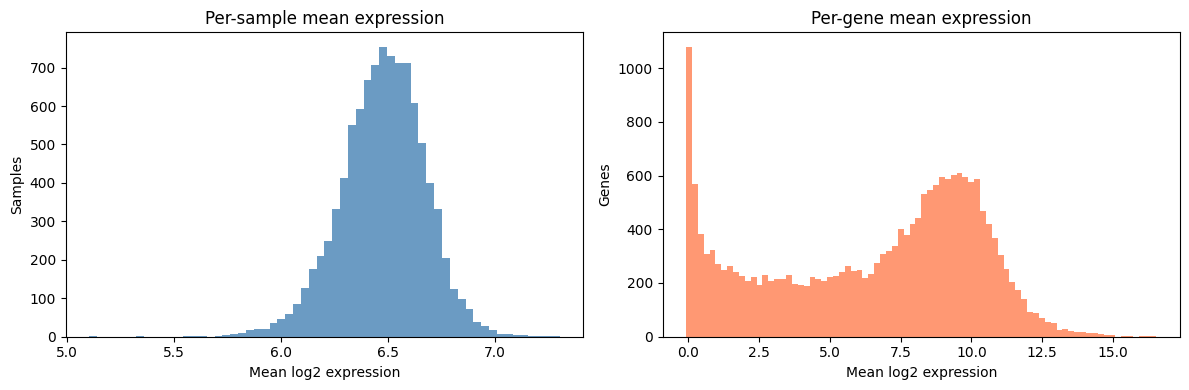

Per-sample mean: 6.477 ± 0.197
Genes with mean > 1: 17,582 / 20,281


In [17]:
# Per-sample mean expression (should be consistent across samples)
sample_means = X.mean(axis=1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(sample_means, bins=60, color='steelblue', alpha=0.8)
axes[0].set_title('Per-sample mean expression')
axes[0].set_xlabel('Mean log2 expression')
axes[0].set_ylabel('Samples')

# Per-gene mean expression
gene_means = X.mean(axis=0)
axes[1].hist(gene_means, bins=80, color='coral', alpha=0.8)
axes[1].set_title('Per-gene mean expression')
axes[1].set_xlabel('Mean log2 expression')
axes[1].set_ylabel('Genes')

plt.tight_layout()
plt.show()

print(f'Per-sample mean: {sample_means.mean():.3f} ± {sample_means.std():.3f}')
print(f'Genes with mean > 1: {(gene_means > 1).sum():,} / {len(gene_means):,}')

**Interpretation:** The per-sample mean expression should be roughly consistent across samples — a large outlier would suggest a batch effect or a failed sample. Genes with very low mean expression across all samples carry little signal and will be filtered out by the `min_mean_expression` threshold in the preprocessing pipeline.

## 4. Cancer Type Breakdown

In [18]:
# Merge metadata with labels
merged = labels.merge(meta, on='sample_id')

# TP53 mutation rate per cancer type
cancer_stats = (
    merged.groupby('primary_disease')['tp53_mutant']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'mutant', 'count': 'total'})
)
cancer_stats['mut_rate'] = (cancer_stats['mutant'] / cancer_stats['total'] * 100).round(1)
cancer_stats.sort_values('mut_rate', ascending=False).head(20)

,mutant,total,mut_rate
primary_disease,,,
uterine carcinosarcoma,52,57,91.2
esophageal carcinoma,157,184,85.3
lung squamous cell carcinoma,413,502,82.3
head & neck squamous cell carcinoma,356,520,68.5
pancreatic adenocarcinoma,103,178,57.9
lung adenocarcinoma,265,515,51.5
stomach adenocarcinoma,203,415,48.9
bladder urothelial carcinoma,198,408,48.5
brain lower grade glioma,249,516,48.3


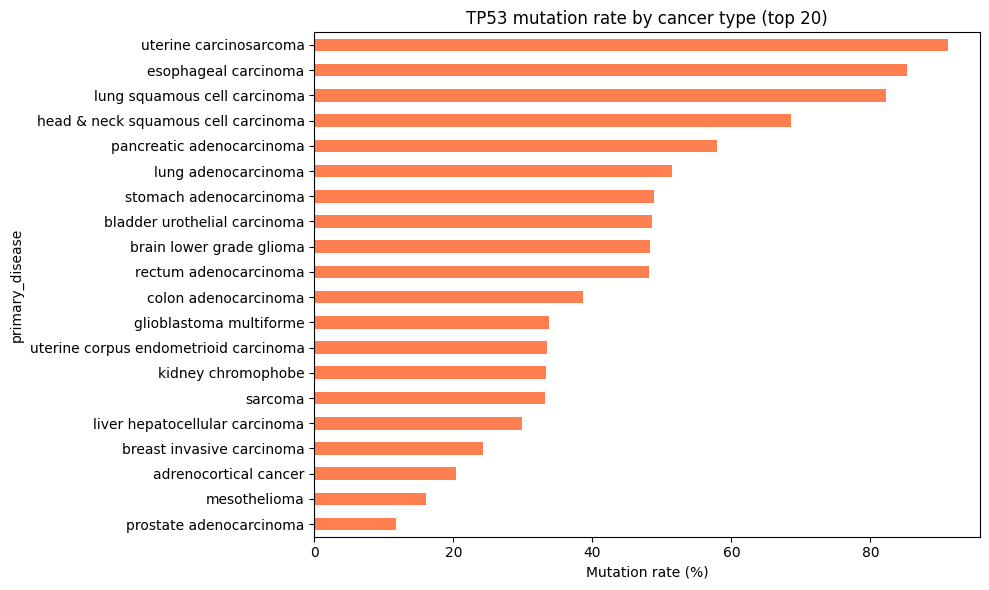

In [19]:
top20 = cancer_stats.sort_values('mut_rate', ascending=False).head(20)
fig, ax = plt.subplots(figsize=(10, 6))
top20['mut_rate'].plot(kind='barh', ax=ax, color='coral')
ax.set_title('TP53 mutation rate by cancer type (top 20)')
ax.set_xlabel('Mutation rate (%)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Interpretation:** TP53 mutation rates vary dramatically by cancer type. Ovarian, colorectal, and lung cancers are known to have very high TP53 mutation rates (~50–96%), while thyroid and kidney cancers rarely mutate TP53 (<10%). This means the binary classifier may partly be learning cancer type rather than pure TP53 biology — a known limitation of pan-cancer modelling. The PCA and per-lineage performance analysis in the training notebook will help assess this.

## 5. PCA — TP53 Status

In [29]:
# Use top 3000 most variable genes for PCA speed
top_var_genes = X.var(axis=0).nlargest(3000).index
X_sub = X[top_var_genes].fillna(0)  # fill any residual NaN with 0

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sub)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(coords, columns=['PC1', 'PC2'], index=X.index)
pca_df = pca_df.join(labels.set_index('sample_id')[['tp53_mutant', 'mutation_type_collapsed']])

print(f'Variance explained: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}')

Variance explained: PC1=16.4%, PC2=9.2%


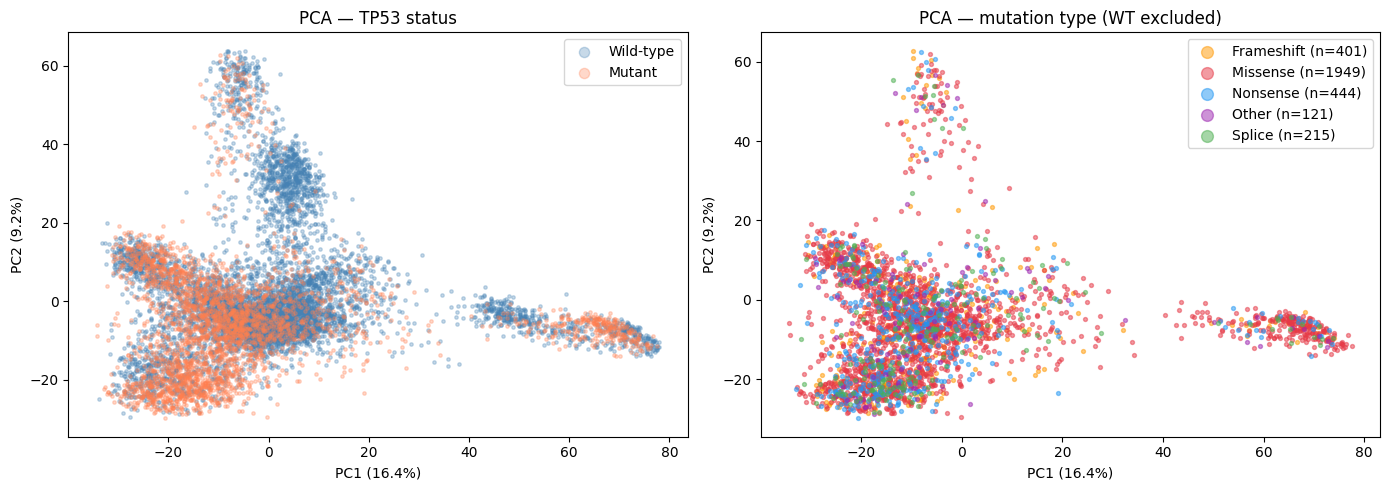

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary
colors = {0: "steelblue", 1: "coral"}
for status, grp in pca_df.groupby("tp53_mutant"):
    label = "Mutant" if status == 1 else "Wild-type"
    axes[0].scatter(grp["PC1"], grp["PC2"], c=colors[status],
                    alpha=0.3, s=6, label=label)
axes[0].set_title("PCA — TP53 status")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[0].legend(markerscale=3)

# Multiclass — WT excluded so mutation types are visible
palette = {
    "Missense":   "#E63946",
    "Nonsense":   "#2196F3",
    "Frameshift": "#FF9800",
    "Splice":     "#4CAF50",
    "Other":      "#9C27B0",
}
mutants_only = pca_df[pca_df["mutation_type_collapsed"] != "WT"]
for mtype, grp in mutants_only.groupby("mutation_type_collapsed"):
    axes[1].scatter(grp["PC1"], grp["PC2"], c=palette.get(mtype, "black"),
                    alpha=0.5, s=8, label=f"{mtype} (n={len(grp)})")
axes[1].set_title("PCA — mutation type (WT excluded)")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[1].legend(markerscale=3, loc="best")

plt.tight_layout()
plt.show()

**Interpretation — TP53 status (left plot):**

The PCA reveals a pan-cancer structure: two distinct arms emerge from a central cloud, almost certainly representing different cancer lineages with very different baseline expression profiles. TP53 mutant and wild-type samples overlap heavily throughout the central cloud, meaning TP53 status alone is not the dominant axis of variation — cancer type is. However, the upper arm (high PC2) is notably enriched for wild-type samples, which likely corresponds to a cancer type with low TP53 mutation rate (e.g. thyroid or kidney). The right arm (high PC1) contains a mix of both, suggesting a different cancer lineage with its own transcriptional identity. This pan-cancer confound is a known limitation: the classifier may partly learn 'what type of cancer is this' rather than purely 'is TP53 mutated'.

**Interpretation — mutation type (right plot):**

All five mutation classes (Missense, Nonsense, Frameshift, Splice, Other) are completely intermixed across the PCA space — there is no visible separation between them. This is biologically expected: regardless of *how* TP53 is disrupted (a point mutation, a frameshift, a splice site change), the downstream transcriptional consequence is similar — p53 target genes (MDM2, CDKN1A, BAX etc.) are dysregulated in a comparable way. This tells us the multiclass task will be genuinely hard: the expression signal does not cleanly distinguish mutation types. The classifier will need to find subtle differences rather than obvious clusters.

## 6. PCA — Cancer Type

Since cancer type appears to drive the main PCA structure, we colour the same PCA by primary disease to confirm this and understand which lineages dominate each region.

/var/folders/cr/hfg_ct216c5_2qfs0mq5m7qh0000gn/T/ipykernel_89522/3765279848.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(cancer_types))


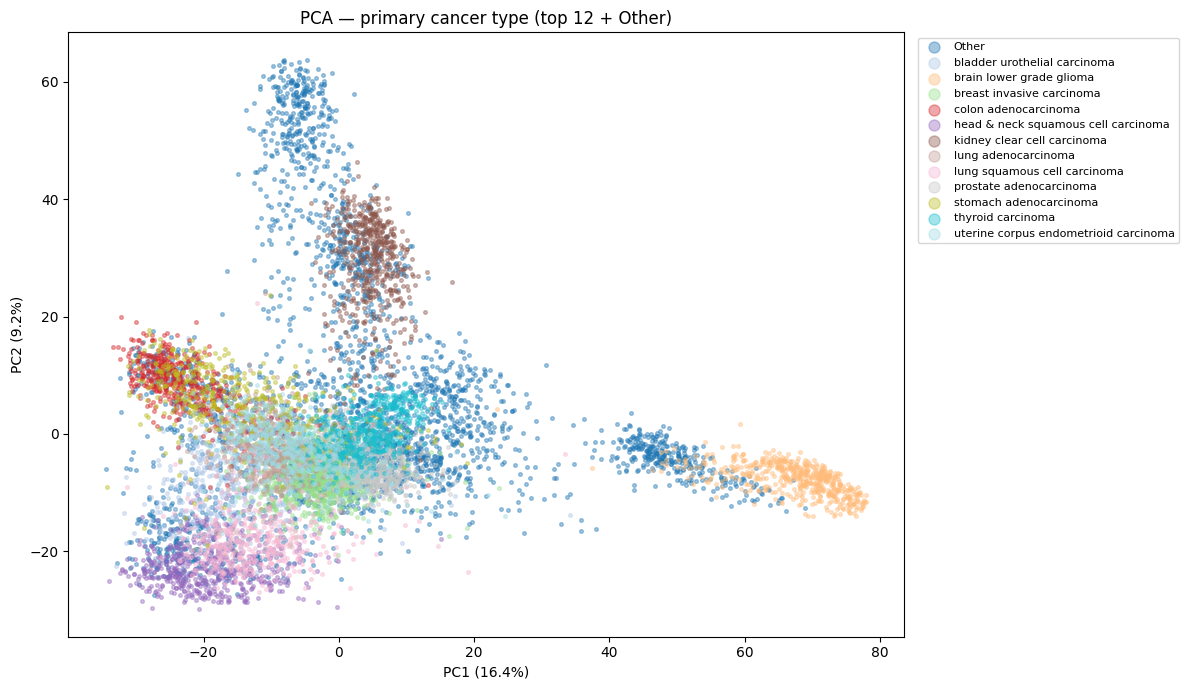

In [31]:
# Merge PCA coords with cancer type
pca_cancer = pca_df.join(meta.set_index('sample_id')[['primary_disease']])

# Keep only the top 12 most frequent cancer types for readability
top_cancers = pca_cancer['primary_disease'].value_counts().head(12).index
pca_cancer['disease_label'] = pca_cancer['primary_disease'].where(
    pca_cancer['primary_disease'].isin(top_cancers), other='Other'
)

# Assign a distinct colour to each cancer type
cancer_types = pca_cancer['disease_label'].unique()
cmap = plt.cm.get_cmap('tab20', len(cancer_types))
cancer_palette = {ct: cmap(i) for i, ct in enumerate(sorted(cancer_types))}

fig, ax = plt.subplots(figsize=(12, 7))
for ct, grp in pca_cancer.groupby('disease_label'):
    ax.scatter(grp['PC1'], grp['PC2'], c=[cancer_palette[ct]],
               alpha=0.4, s=7, label=ct)
ax.set_title('PCA — primary cancer type (top 12 + Other)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(markerscale=3, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

**Interpretation:** The two arms are driven entirely by specific cancer types:

Right arm (PC1 ~60–80): Almost exclusively brain lower grade glioma (orange) — brain tumours have a fundamentally different transcriptional programme from other cancers, driven by neuronal/glial gene expression unrelated to TP53

Upper arm (PC2 ~40–65): Dominated by kidney clear cell carcinoma (brown) and bladder urothelial carcinoma — both are known to have very low TP53 mutation rates (<10%), which explains why this arm was WT-enriched in the first plot

Left cluster: Gastrointestinal and squamous cancers — colon adenocarcinoma (red), stomach (yellow), head & neck squamous (purple) — these cluster tightly together due to shared epithelial transcriptional programmes

Central cloud: The majority of cancer types overlap here, including breast, lung, and prostate
What this means for the model: The classifier will see these lineage-specific expression signatures as strong features. High TP53 mutation rate cancers (colon, head & neck) cluster in the left, low mutation rate cancers (kidney, brain glioma) form the arms. The model risks learning "tissue of origin" as a proxy for TP53 status rather than the true transcriptional fingerprint of p53 dysregulation. This is the core limitation of pan-cancer modelling without lineage correction.

## 7. Mutation Type vs Cancer Type

Does the *type* of TP53 mutation depend on the cancer lineage? Some cancers accumulate mutations via specific mechanisms (e.g. UV exposure → missense, microsatellite instability → frameshift), so mutation type profiles may differ across cancer types — which would make the two-stage multiclass task easier for certain lineages.

In [38]:
# Mutant samples only — merge mutation type with cancer type
mutant_df = merged[merged['tp53_mutant'] == 1].copy()

# Keep cancer types with at least 30 mutant samples for reliable proportions
mutant_counts_per_cancer = mutant_df['primary_disease'].value_counts()
enough = mutant_counts_per_cancer[mutant_counts_per_cancer >= 30].index
mutant_df = mutant_df[mutant_df['primary_disease'].isin(enough)]

# Mutation type proportions per cancer type
ct_mt = (
    mutant_df.groupby(['primary_disease', 'mutation_type_collapsed'])
    .size()
    .unstack(fill_value=0)
)
# Reorder columns
col_order = [c for c in ['Missense', 'Nonsense', 'Frameshift', 'Splice', 'Other'] if c in ct_mt.columns]
ct_mt = ct_mt[col_order]

# Normalise to row percentages
ct_mt_pct = ct_mt.div(ct_mt.sum(axis=1), axis=0) * 100
ct_mt_pct = ct_mt_pct.sort_values('Missense', ascending=False)

print(f"Cancer types shown: {len(ct_mt_pct)}")
ct_mt_pct.round(1)

Cancer types shown: 17


mutation_type_collapsed,Missense,Nonsense,Frameshift,Splice,Other
primary_disease,,,,,
uterine carcinosarcoma,75.0,9.6,7.7,7.7,0.0
brain lower grade glioma,74.7,7.2,10.0,4.8,3.2
colon adenocarcinoma,73.1,12.0,7.4,4.0,3.4
glioblastoma multiforme,73.1,9.6,7.7,3.8,5.8
prostate adenocarcinoma,70.7,3.4,15.5,10.3,0.0
uterine corpus endometrioid carcinoma,67.4,9.6,12.4,3.9,6.7
bladder urothelial carcinoma,65.7,20.2,9.6,2.5,2.0
rectum adenocarcinoma,63.6,16.9,11.7,7.8,0.0
lung squamous cell carcinoma,61.5,11.4,13.1,8.7,5.3


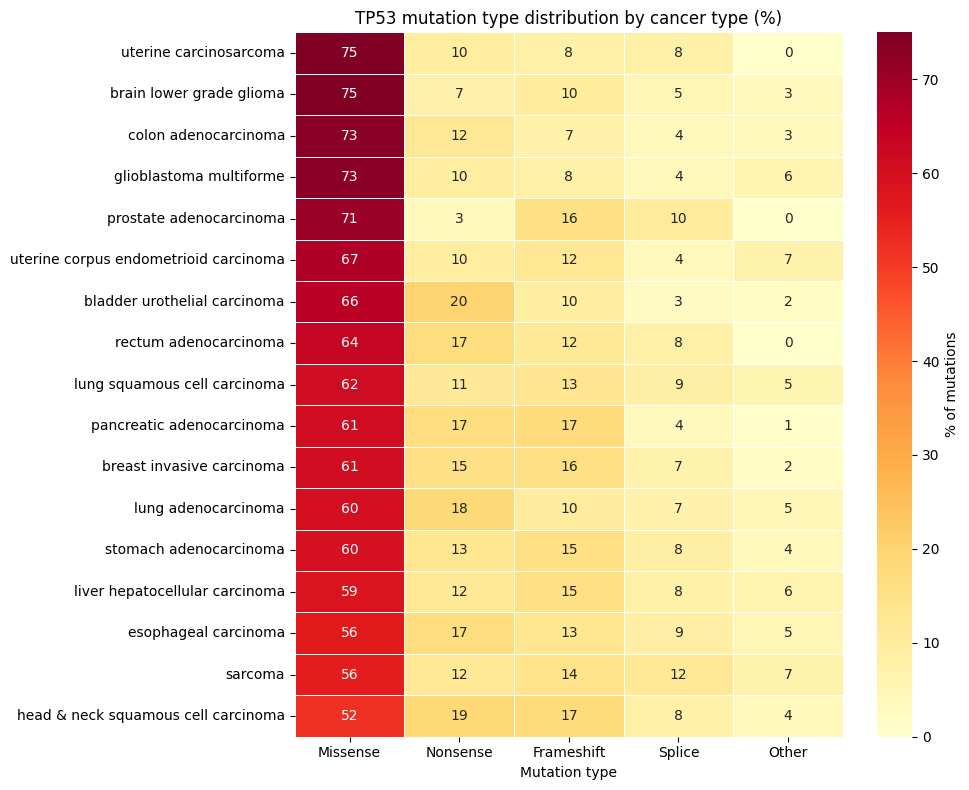

In [39]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    ct_mt_pct,
    annot=True, fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.4,
    cbar_kws={'label': '% of mutations'},
    ax=ax,
)
ax.set_title('TP53 mutation type distribution by cancer type (%)')
ax.set_xlabel('Mutation type')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

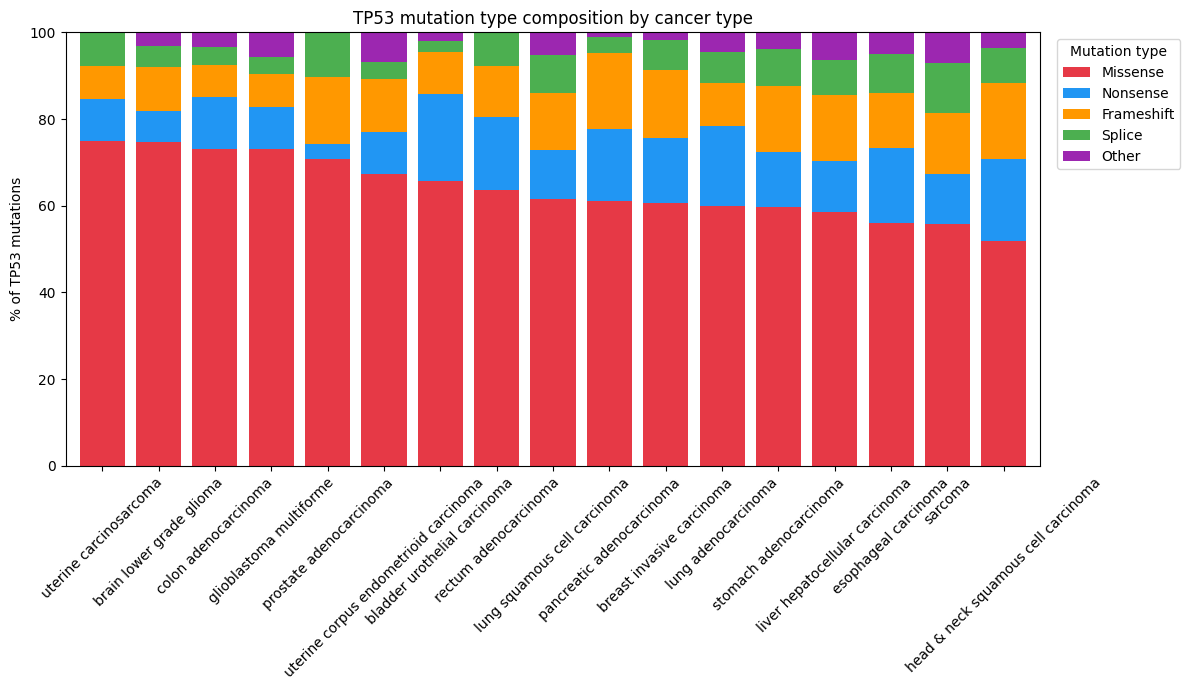

In [40]:
palette = {
    'Missense':   '#E63946',
    'Nonsense':   '#2196F3',
    'Frameshift': '#FF9800',
    'Splice':     '#4CAF50',
    'Other':      '#9C27B0',
}

fig, ax = plt.subplots(figsize=(12, 7))
ct_mt_pct.plot(
    kind='bar', stacked=True,
    color=[palette[c] for c in ct_mt_pct.columns],
    ax=ax, width=0.8,
)
ax.set_title('TP53 mutation type composition by cancer type')
ax.set_ylabel('% of TP53 mutations')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Mutation type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [41]:
from scipy.stats import chi2_contingency
import numpy as np

chi2, p, dof, _ = chi2_contingency(ct_mt)

# Cramér's V — effect size (0 = no association, 1 = perfect)
n = ct_mt.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct_mt.shape) - 1)))

print(f"Chi-squared test: mutation type vs cancer type")
print(f"  chi2 = {chi2:.1f}, df = {dof}, p = {p:.2e}")
print(f"  Cramér's V (effect size) = {cramers_v:.3f}  [0=none, 1=perfect]")
print()

# Range of Missense % across cancer types
print(f"Missense % range: {ct_mt_pct['Missense'].min():.1f}% – {ct_mt_pct['Missense'].max():.1f}%")
print(f"  → Missense is the dominant class in every single cancer type")

Chi-squared test: mutation type vs cancer type
  chi2 = 130.4, df = 64, p = 1.91e-06
  Cramér's V (effect size) = 0.104  [0=none, 1=perfect]

Missense % range: 52.0% – 75.0%
  → Missense is the dominant class in every single cancer type


**Interpretation:**

The chi-squared test is statistically significant (p << 0.05), but the **effect size (Cramér's V) is weak** — meaning cancer type and mutation type are technically associated, but the association is not strong enough to be practically useful as a predictive feature.

The stacked bar chart makes the reason clear: **Missense is the dominant mutation type in every single cancer type**, ranging only from ~51% (head & neck squamous) to ~75% (uterine carcinosarcoma). No cancer type has a fundamentally different mutation type profile — they all have the same rank order, just with slightly different proportions in the minority classes.

**Why adding cancer type as a feature would not help much:**
- A classifier using cancer type would still overwhelmingly predict Missense regardless of lineage, because that is always the right answer
- The variation is concentrated in Nonsense, Frameshift, Splice, and Other — which are already the hardest classes to predict and represent only 25–50% of mutations per cancer type
- The model already implicitly captures lineage information through expression data (as the PCA showed), so explicitly adding cancer type adds little new signal

**Conclusion:** Mutation type prediction is hard not because we are missing the cancer type feature, but because all mutation types — regardless of mechanism — produce similar transcriptional perturbations. The bottleneck is biological, not feature engineering.

## 6. TCGA vs CCLE — Side-by-side Summary

In [32]:
ccle_labels = pd.read_csv('data/processed/tp53_labels.csv')
ccle_X      = pd.read_csv('data/processed/expression_matched.csv.gz', index_col=0, nrows=0)

summary = pd.DataFrame({
    'TCGA': [
        X.shape[0],
        X.shape[1],
        int(labels['tp53_mutant'].sum()),
        int((labels['tp53_mutant'] == 0).sum()),
        round(X.values.mean(), 3),
    ],
    'CCLE': [
        ccle_labels.shape[0],
        len(ccle_X.columns),
        int(ccle_labels['tp53_mutant'].sum()),
        int((ccle_labels['tp53_mutant'] == 0).sum()),
        None,  # computed separately to avoid loading full CCLE matrix
    ]
}, index=['Total samples', 'Genes', 'TP53 mutant', 'TP53 wild-type', 'Expression mean'])

summary

,TCGA,CCLE
Total samples,9701.000,1719.0
Genes,20281.000,19215.0
TP53 mutant,3130.000,997.0
TP53 wild-type,6571.000,722.0
Expression mean,6.477,NaN


In [33]:
# Mutation type counts side by side
tcga_mc = labels['mutation_type_collapsed'].value_counts().rename('TCGA')
ccle_mc = ccle_labels['mutation_type_collapsed'].value_counts().rename('CCLE')
pd.concat([tcga_mc, ccle_mc], axis=1).fillna(0).astype(int)

,TCGA,CCLE
mutation_type_collapsed,,
WT,6571,722
Missense,1949,620
Nonsense,444,113
Frameshift,401,58
Splice,215,0
Other,121,189
In-frame indel,0,9
Synonymous,0,8


### note that we get zero for In-frame indel and synonymous because we combined them under Other